In [ ]:
import numpy as np
import itertools
from matplotlib import pylab
import plotly.graph_objs as go
from plotly.offline import iplot,init_notebook_mode
init_notebook_mode(connected=True)

#Класс реализующий нейронную сеть
class network:
    def __init__(self,size):
        self.weights=np.zeros(size+1) # задаём нулевые веса
    
    # Функция, вычисляющая расстояние Хеминга
    def calculate_E(self,real_outputs,inputs):
        predict_outputs=np.array(self.predict(inputs) > 0.5, dtype=int)
        return sum(abs(real_outputs - predict_outputs))
    
    # Функция активации
    def activation_function(self,x):
        return np.array(x > 0.5,dtype=int)
    def deviation_activation_function(self,x):
        return 1
    def learn(self, inputs, outputs, norm=0.3, show=False):
        if show==True:
            output=[]
            k=0
            E=self.calculate_E(full_outputs,full_inputs)
            while E!=0 and k<100:
                predict_outputs=self.predict(inputs)
                output.append([k,np.round(self.weights,2),
                               np.array(self.predict(full_inputs)>0.5,
                                        dtype=int),E])
                error=outputs-predict_outputs
                correction=(norm*
                            np.dot(np.column_stack((np.ones(len(inputs)),
                                                    inputs)).T,
                                   error*
                                   self.deviation_activation_function(inputs)))
                self.weights+=correction
                E=self.calculate_E(full_outputs,full_inputs)
                k+=1
            output.append([k,np.round(self.weights,2),
                           np.array(self.predict(full_inputs)>0.5,
                                    dtype=int),E])
            return output
        else:
            k=0
            E=self.calculate_E(full_outputs,full_inputs)
            while E!=0 and k<100:
                predict_outputs=self.predict(inputs)
                error=outputs-predict_outputs
                correction=(norm*
                            np.dot(np.column_stack((np.ones(len(inputs)),
                                                    inputs)).T,
                                   error*
                                   self.deviation_activation_function(inputs)))
                self.weights+=correction
                E=self.calculate_E(full_outputs,full_inputs)
                k+=1
    def predict(self,inputs):
        #добавляется единичный вектор-столбец
        inputs=np.column_stack((np.ones(len(inputs)),inputs))
        return self.activation_function(np.dot(inputs,self.weights.T))

In [13]:
#Задание исходных данных
def bool_func(x):
    return (not(not( x[0] | x[1] )) | x[2] | x[3])

full_inputs=[]
full_outputs=[]
for i in range(16):
    full_inputs.append(list(map(int,bin(i)[2:].rjust(4,'0'))))
for i in full_inputs:
    full_outputs.append(bool_func(i))
full_inputs=np.array(full_inputs)
full_outputs=np.array(full_outputs)

#Вывод таблицы истинности
print("Таблица истинности:")
for i,j in zip(full_inputs,full_outputs):
    print(i,j)


Таблица истинности:
[0 0 0 0] False
[0 0 0 1] False
[0 0 1 0] False
[0 0 1 1] False
[0 1 0 0] True
[0 1 0 1] False
[0 1 1 0] False
[0 1 1 1] False
[1 0 0 0] True
[1 0 0 1] False
[1 0 1 0] False
[1 0 1 1] False
[1 1 0 0] True
[1 1 0 1] False
[1 1 1 0] False
[1 1 1 1] False


In [16]:
#Обучение сети на всех данных
netw=network(4)
output=netw.learn(full_inputs,full_outputs,show=True)

#Вывод результатов
trace = go.Table(
    header=dict(values=['Номер эпохи k', 
                        'Вектор весов w',
                        'Выходной вектор y',
                        'Суммарная ошибка E']),
    cells=dict(values=[*list(zip(*output))])
)
data = [trace] 
iplot(data, filename = 'basic_table')


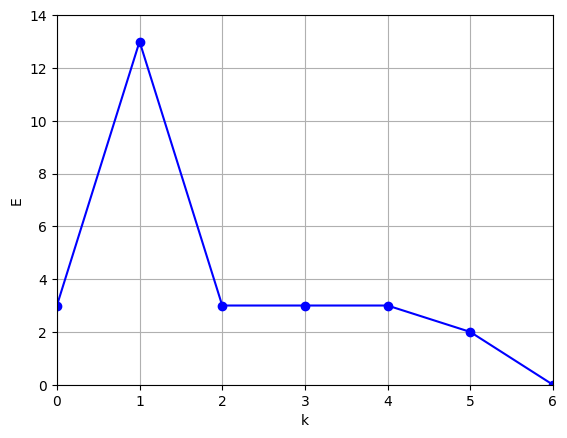

In [17]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Пороговая функция, все данные
error=[i[-1] for i in output]
pylab.plot(error,'-ob')
pylab.xlabel('k')
pylab.ylabel('E')
pylab.grid(True)
pylab.axis([0, len(error)-1, 0, max(error)+1])
pylab.show()


In [6]:
#Класс для сети с сигмоидальной функцией активации
class new_network(network):
    def activation_function(self,x):
        return 1/2*(x/(1+np.abs(x))+1)
    def deviation_activation_function(self,x):
        x=np.column_stack((np.ones(len(x)),x))
        x=np.dot(x,self.weights.T)
        return 1/(2*(1+np.abs(x))**2)
    
#обучение сети с сигмоидальной функцией на всех данных
netw=new_network(4)
output_sigma=netw.learn(full_inputs,full_outputs,show=True)

#вывод результатов
trace = go.Table(
    header=dict(values=['Номер эпохи k', 
                        'Вектор весов w',
                        'Выходной вектор y',
                        'Суммарная ошибка E']),
    cells=dict(values=[*list(zip(*output_sigma))])
)
data = [trace] 
iplot(data, filename = 'basic_table')


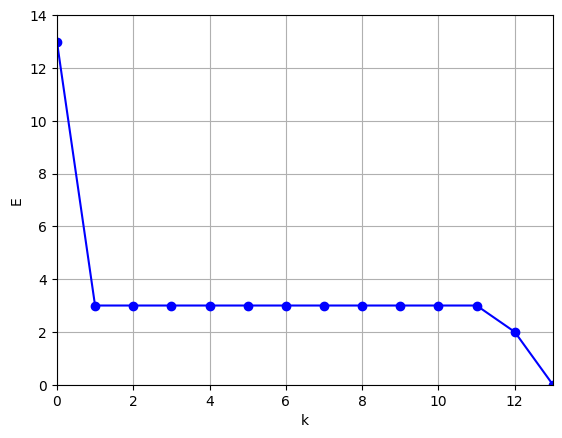

In [7]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Сигмоидальная функция, все данные
error=[i[-1] for i in output_sigma]
pylab.plot(error,'-ob')
pylab.xlabel('k')
pylab.ylabel('E')
pylab.grid(True)
pylab.axis([0, len(error)-1, 0, max(error)+1])
pylab.show()


In [8]:
#Функция для нахождения минимальных входных данных для сети
def find_min_inputs(network):
    for i in range(15,0,-1):
        new_inputs=itertools.combinations(range(16),i)
        for j in new_inputs:
            
            inputs=[]
            outputs=[]
            for i in j:
                inputs.append(list(map(int,bin(i)[2:].rjust(4,'0'))))
            for i in inputs:
                outputs.append(bool_func(i))
            netw=network(4)   
            netw.learn(inputs,outputs,norm=0.3)
            if all(np.array(netw.predict(full_inputs)>0.5,
                            dtype=int)==full_outputs):
                min_inputs={'weights':netw.weights,'inputs':j}
                break
    return min_inputs

#Функция для проверки правильности вычисленных входных данных
def check_min_inputs(network,min_inputs):
    inputs=[]
    outputs=[]
    for i in min_inputs['inputs']:
        inputs.append(list(map(int,bin(i)[2:].rjust(4,'0'))))
    for i in inputs:
        outputs.append(bool_func(i))
    
    inputs=np.array(inputs)
    outputs=np.array(outputs)
    
    print('input sample ',*inputs)

    
    netw=network(4)
    output=netw.learn(inputs,outputs,show=True)

    print('weights:',min_inputs['weights'])
    print('network outputs ',np.array(netw.predict(full_inputs)>0.5,
                                      dtype=int))
    print('real ouptputs   ',full_outputs)
    
    #вывод результатов
    trace = go.Table(
        header=dict(values=['Номер эпохи k', 
                            'Вектор весов w',
                            'Выходной вектор y',
                            'Суммарная ошибка E']),
        cells=dict(values=[*list(zip(*output))])
    )
    data = [trace]
    iplot(data, filename = 'basic_table')
    return output


In [9]:
#Вычисление минимального набора векторов и вывод результатов
#Пороговая функция
min_inputs=find_min_inputs(network)
output=check_min_inputs(network,min_inputs)


input sample  [0 0 0 0] [1 1 0 0] [1 1 1 1]
weights: [ 0.6 -0.3 -0.3  0.6  0.6]
network outputs  [1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1]
real ouptputs    [1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1]


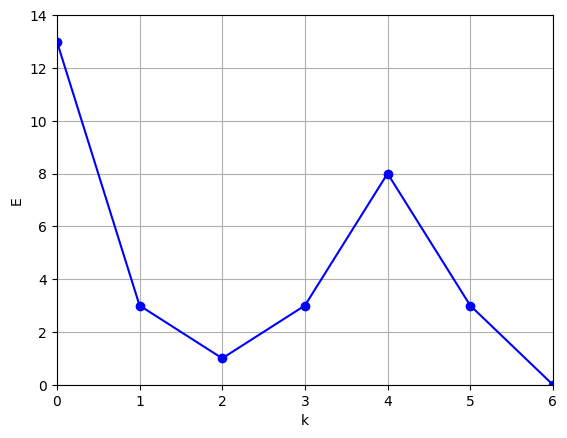

In [10]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Пороговая функция, минимальный набор данных
error=[i[-1] for i in output]
pylab.plot(error,'-ob')
pylab.xlabel('k')
pylab.ylabel('E')
pylab.grid(True)
pylab.axis([0, len(error)-1, 0, max(error)+1])
pylab.show()


In [11]:
#Вычисление минимального набора векторов и вывод результатов
#Сигмоидальная функция
min_inputs=find_min_inputs(new_network)
output_sigma=check_min_inputs(new_network,min_inputs)


input sample  [0 0 0 1] [1 1 0 0] [1 1 1 0]
weights: [ 0.1990395  -0.19934696 -0.19934696  0.52648511  0.39838647]
network outputs  [1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1]
real ouptputs    [1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1]


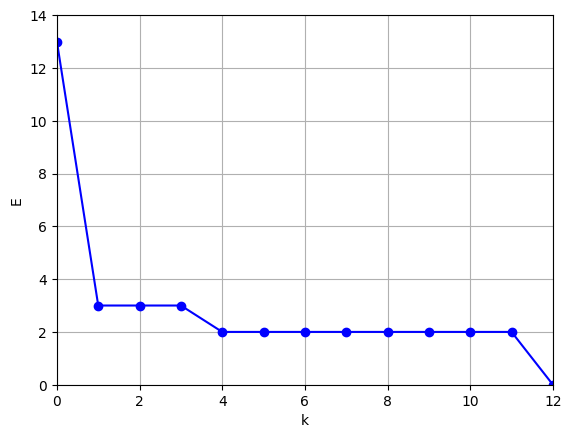

In [12]:
#Построение графика зависимости суммарной ошибки от номера эпохи
#Сигмоидальная функция, минимальный набор данных
error=[i[-1] for i in output_sigma]
pylab.plot(error,'-ob')
pylab.xlabel('k')
pylab.ylabel('E')
pylab.grid(True)
pylab.axis([0, len(error)-1, 0, max(error)+1])
pylab.show()
